# Use the Pisa Track

In [1]:
import numpy as np
import pandas as pd

import os, sys, tqdm, copy

import tqdm
import tqdm.notebook

import matplotlib.pyplot as plt
import matplotlib

style = [
    # 'seaborn-ticks',
    {
        'figure.dpi': 300,
        'font.size': 12,
        'image.cmap': 'inferno',
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman'] + plt.rcParams['font.serif'],
        'xtick.top': True,
        'xtick.direction': 'in',
        'ytick.right': True,
        'ytick.direction': 'in',
        'mathtext.fontset': 'cm'
        }]
plt.style.use(style)

import scipy.io

In [2]:
import os, sys

# github_dir = '/Users/dingshandeng/github/ysoisochrone/'

# # os.chdir(os.path.join(github_dir, 'tests'))
# sys.path.append(os.path.join(github_dir))

# import ysoisochrone.utils as utils
# import ysoisochrone.bayesian as bayesian
# import ysoisochrone.plotting as plotting
import ysoisochrone

In [3]:
df_prop = pd.read_csv('./example_targets.csv', skiprows=6)

# For test targets from Lupus
toobright = [] # ['0']  
toofaint = [] # ['0']
median_age = 1.0 # Myrs	

err_Teff = ysoisochrone.utils.assign_unc_teff(df_prop['Teff[K]'].values)
err_Lumi = ysoisochrone.utils.assign_unc_lumi(df_prop['Luminosity[Lsun]'].values)
df_prop['e_Teff[K]'] = err_Teff
df_prop['e_Luminosity[Lsun]'] = err_Lumi

# you need to specify the source names
toobright = ['J11065906-7718535','J11094260-7725578',
   		     'J11105597-7645325','J11183572-7935548']
toofaint = ['J10533978-7712338','J11063945-7736052','J11082570-7716396',
            'J11111083-7641574','J11160287-7624533']

# the median age for Cham I star-forming region
median_age = 6.48 # Myrs, the age took from Pasucci+2016 choice

# form the df_toobright and df_toofaint only for plot
idx_toobright = []
idx_toofaint  = []
for idx_t in df_prop.index:
    if df_prop.loc[idx_t, 'Source'] in toobright:
        idx_toobright.append(idx_t)
    if df_prop.loc[idx_t, 'Source'] in toofaint:
        idx_toofaint.append(idx_t)

df_toobright = df_prop.loc[idx_toobright]
df_toofaint = df_prop.loc[idx_toofaint]

In [4]:
# ysoisochrone.plotting.simple_plot_hr_diagram_feiden_n_baraffe(df_prop)

## Available tracks

'Baraffe2015', 'Feiden2016', 'Feiden2016_magnetic', 'parsec_v1p2', 'parsec_v2p0', 'mist_v1p2', 'siess2000', 'spots0169', 'spots0339', 'spots0508', 'spots0847', 'pisa'

using the built in isochrones
-----------------------
0.10 Msun is skipped because it is smaller than the grid min mass of 0.20 Msun
0.20 Msun is skipped because it is smaller than the grid min mass of 0.20 Msun


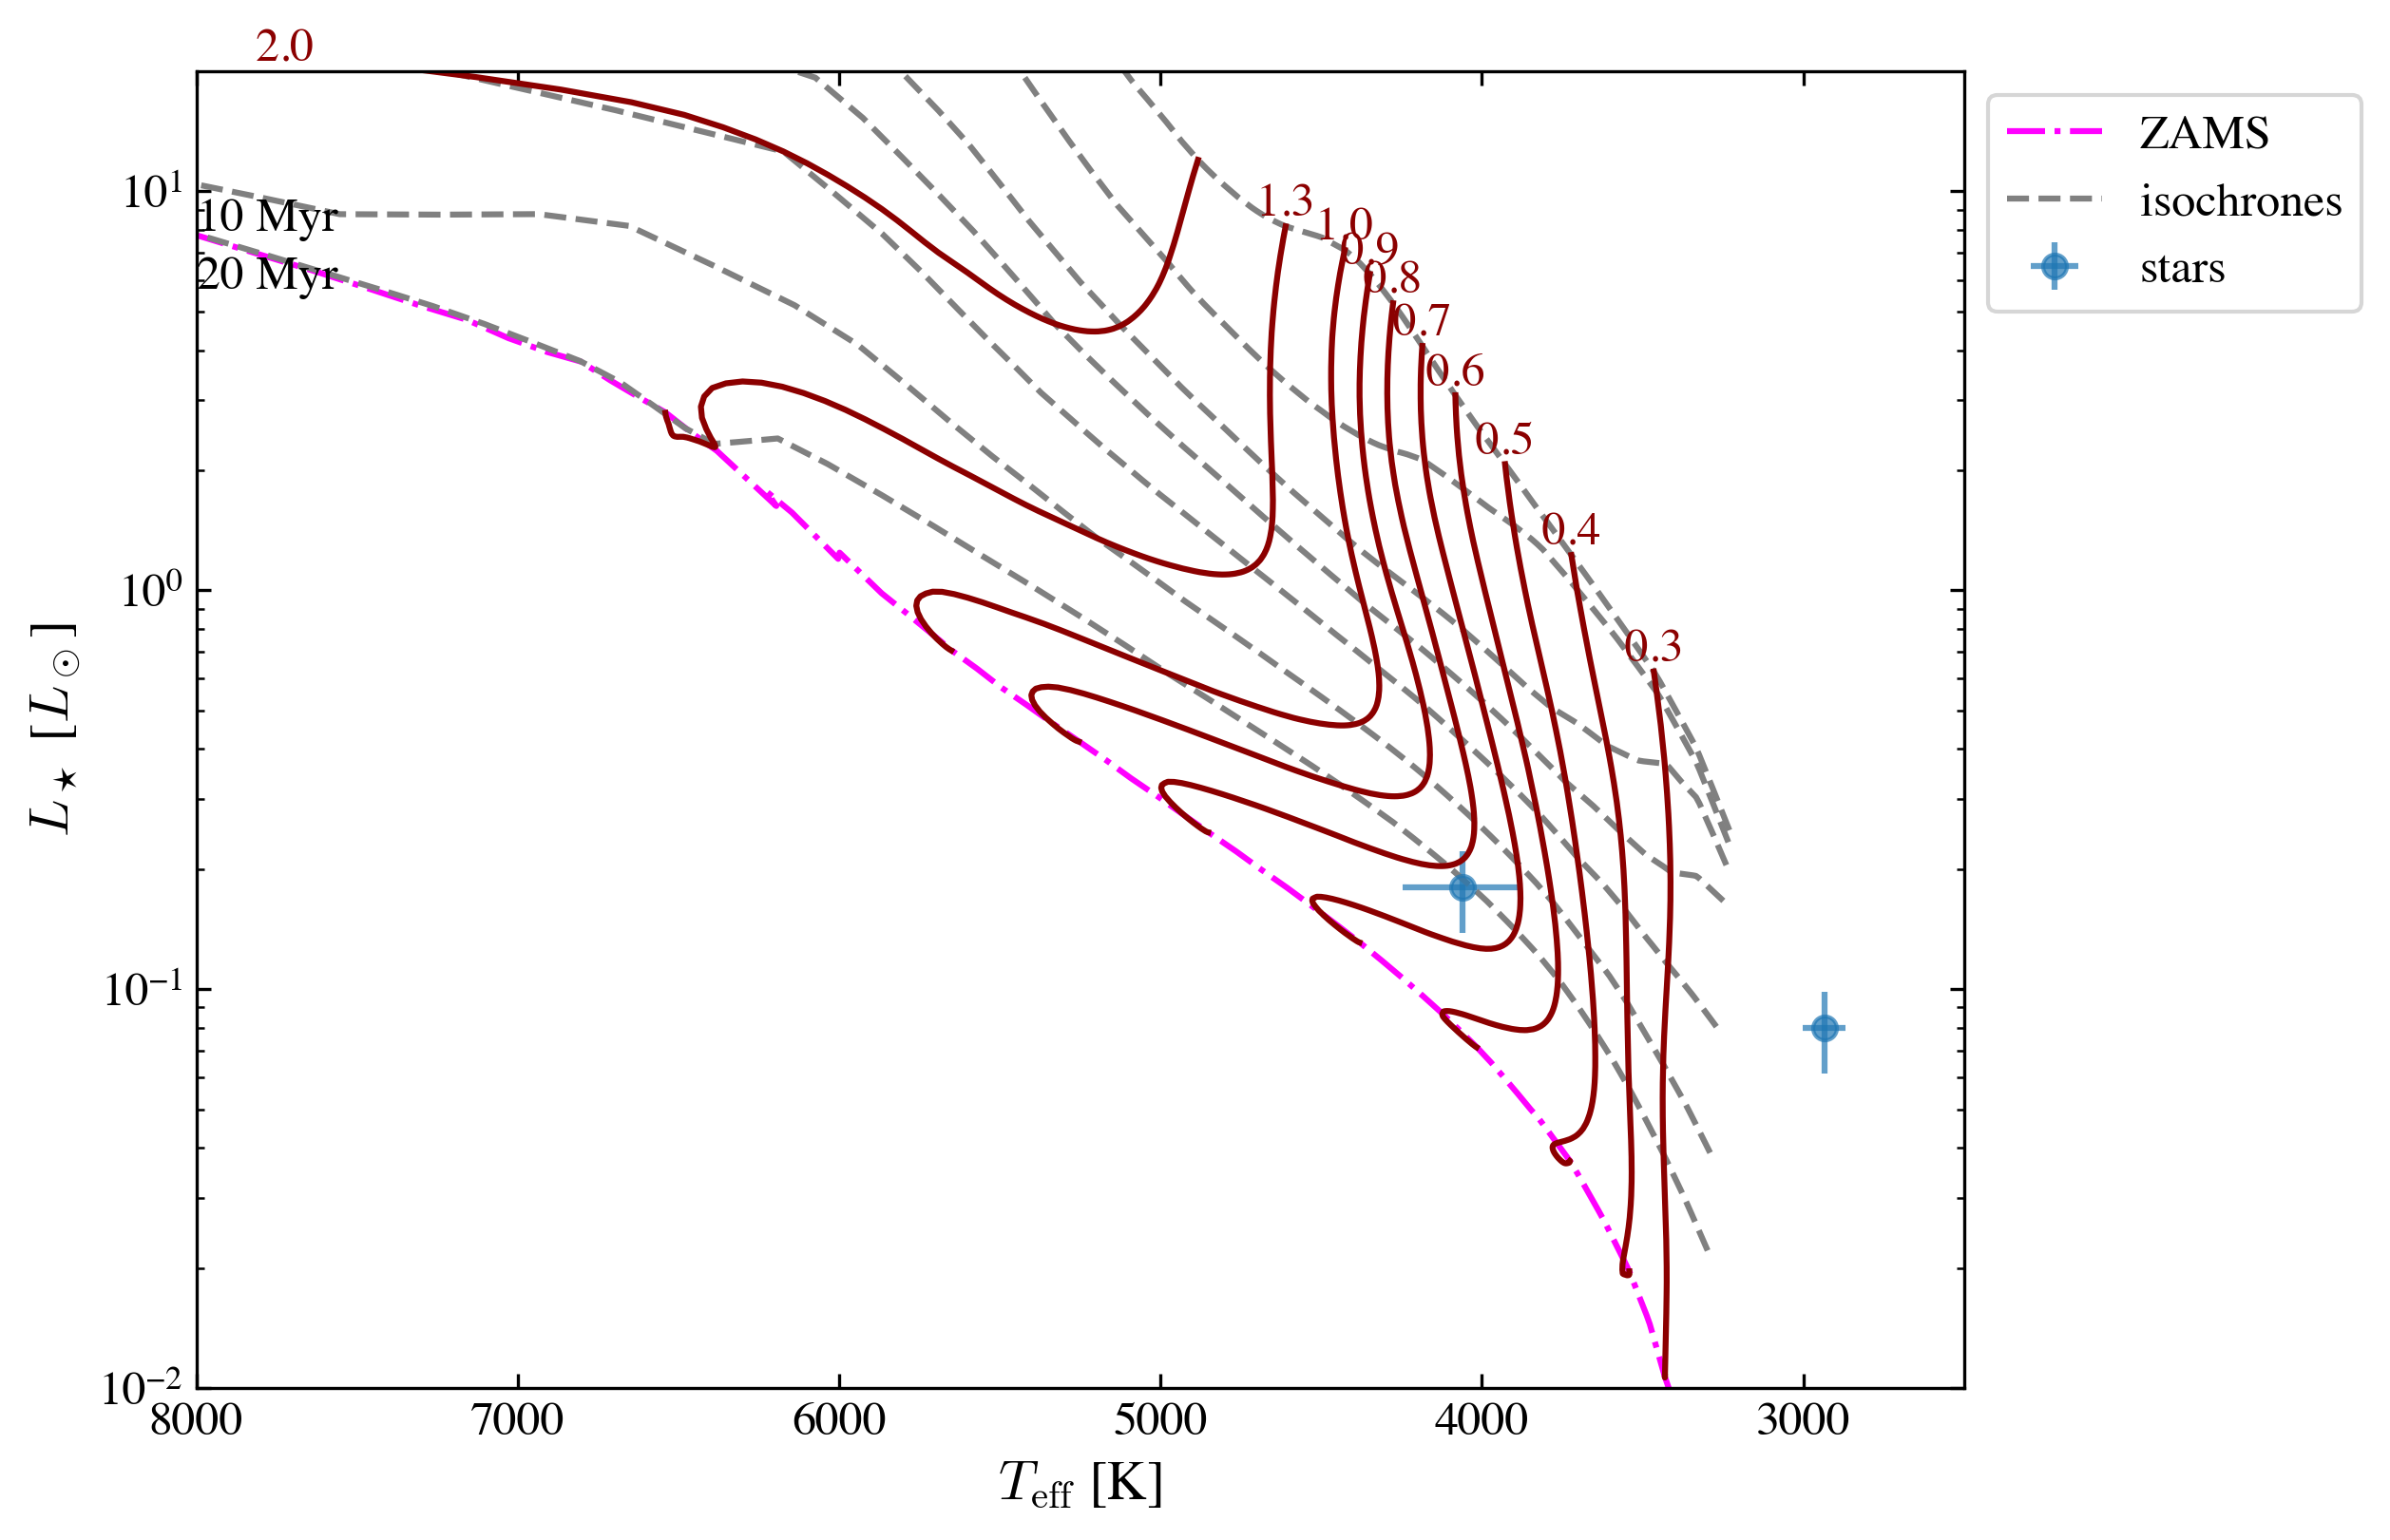

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

isochrone = ysoisochrone.isochrone.Isochrone()
# mat_file_dir = './isochrones_data/Baraffe_AgeMassGrid_YSO_up100Myrs_matrix.mat'

# isochrone.set_tracks('customize', load_file=mat_file_dir)

# isochrone.set_tracks('Feiden2016_magnetic')

isochrone.set_tracks('Pisa')

# ysoisochrone.plotting.plot_hr_diagram(isochrone, df_prop, ax_set=ax, 
#                                       ages_to_plot=[0.5e6, 1.0e6, 2.0e6, 3.0e6, 5.0e6, 10.0e6, 50.0e6, 100.0e6], 
#                                       masses_to_plot=[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 3.0])

# ysoisochrone.plotting.plot_hr_diagram(isochrone, ax_set=ax, 
#                                       masses_to_plot=[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

ysoisochrone.plotting.plot_hr_diagram(isochrone, df_prop[1:3], ax_set=ax, 
                                      ages_to_plot=[0.5e6, 1.0e6, 2.0e6, 3.0e6, 5.0e6, 10.0e6, 20.0e6], 
                                      masses_to_plot=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.3, 2.0],
                                      xlim_set=[8000, 2500], ylim_set=[0.01, 20.0])


# ax.set_xlim(7000, 5000)
# ax.set_ylim(0.5, 10) # , 50.0)
# ax.set_xscale("log")
# ax.set_xlabel()

plt.show()

  0%|          | 0/2 [00:00<?, ?it/s]

using the built in isochrones
-----------------------


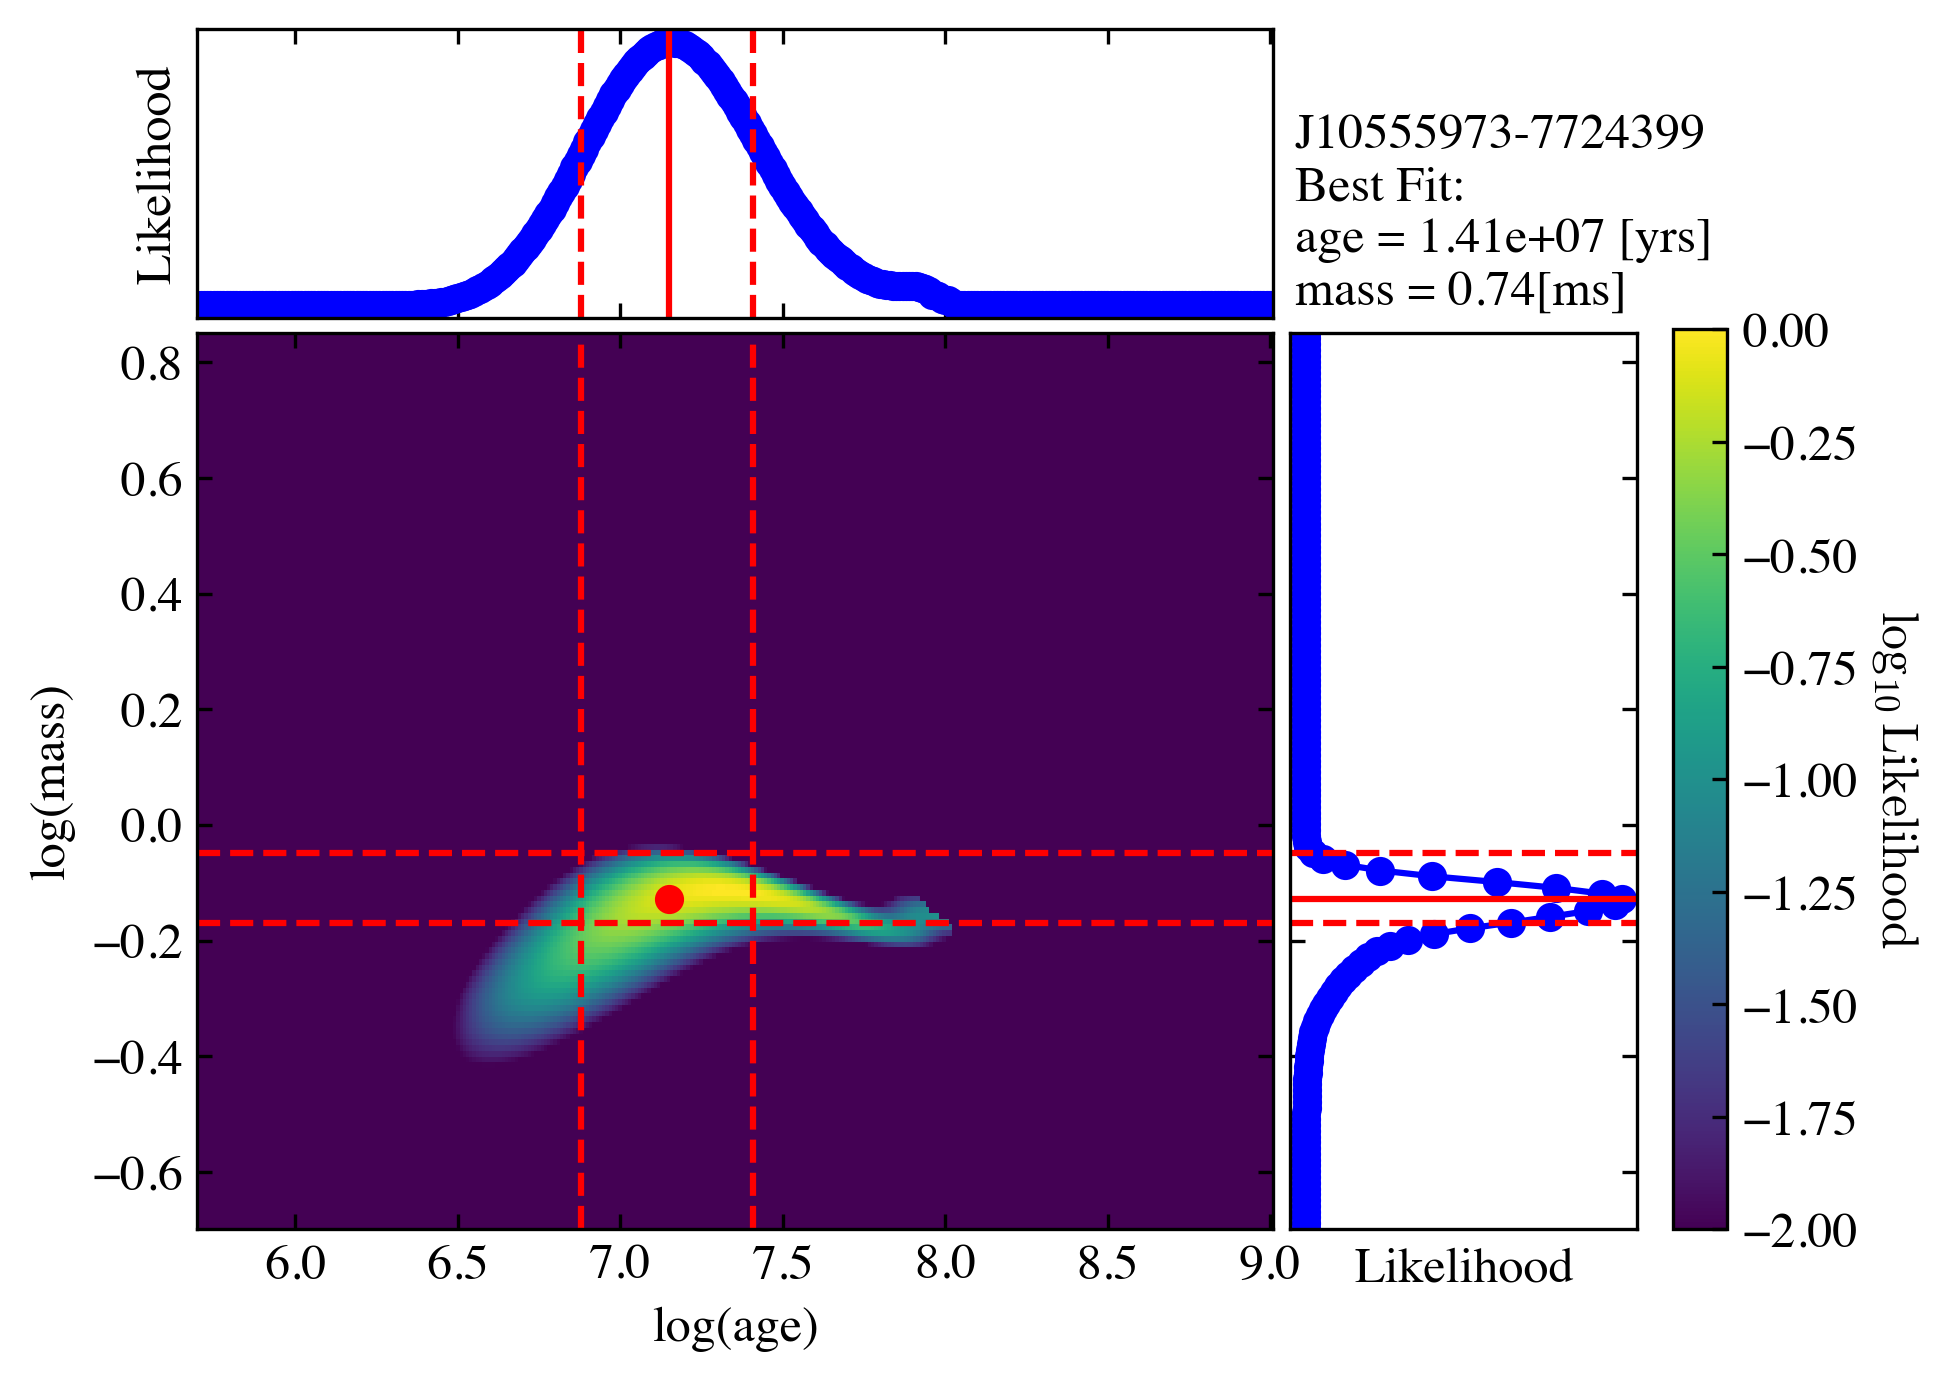

100%|██████████| 2/2 [00:00<00:00,  7.68it/s]

using the built in isochrones
-----------------------


In [13]:
best_logmass_output, best_logage_output, lmass_all, lage_all, flag_all =\
    ysoisochrone.bayesian.derive_stellar_mass_age(df_prop[1:3], model='pisa', plot=True, toobright=toobright, toofaint=toofaint, median_age=median_age, force_through=True)

In [16]:
print("logmass\n", best_logmass_output)
print("logage\n", best_logage_output)
print("flags\n", flag_all)

logmass
 [[-0.12897 -0.16897 -0.04897]
 [     nan      nan      nan]]
logage
 [[7.14897 6.87897 7.40897]
 [    nan     nan     nan]]
flags
 ['good', 'out_of_grid_T']
